**Author:** Salvador Navas  
**Reference model:** Little River Experimental Watershed (LREW), Georgia, USA  
**Sources:** [SWATdata](https://github.com/chrisschuerz/SWATdata) · [USDA-ARS LREW](https://www.ars.usda.gov/southeast-area/tifton-ga/southeast-watershed-research/docs/little-river-experimental-watershed-lrew/)

### SWAT+ — Automated climate-change simulation with `pyhydra`

The **Little River Experimental Watershed** is a 334 km² USDA-ARS research watershed in south-central
Georgia. It is one of the most intensively monitored watersheds in the USA and has been used in
hundreds of SWAT publications. A reference SWAT+ model is distributed via the
[SWATdata](https://github.com/chrisschuerz/SWATdata) R/Python package; this notebook does not recalibrate it by default.

**SWAT+ Linux binary** (runs inside Docker):
```bash
# Download from SWAT+ website → Software → SWAT+ Executable
wget https://bitbucket.org/swatplus/swatplus/downloads/swatplus_linux_rev61.zip
unzip swatplus_linux_rev61.zip -d /workspace/tools/swatplus/
```

**CMIP6 climate data** (public, from ESGF):
Use `notebooks/data_sources/climate_change/ESGF_download.ipynb`, then apply bias
correction with `notebooks/climate/bias_correction.ipynb`.

Workflow:
1. Download LREW model (auto via SWATdata)
2. Read station metadata and reference climate
3. Generate CC climate inputs (CMIP6 SSP2-4.5 / SSP5-8.5)
4. Optionally run SWAT+ for each scenario
5. Extract and visualise discharge regime changes


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, shutil, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pyhydra.modeling.hydrology.swat import (
    write_swatplus_precipitation_files,
    write_swatplus_temperature_files,
    edit_file_cio,
    run_swat,
)

# Portable repo-root / data-dir resolution (local clone, Docker, Azure ML)
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR',  str(REPO_ROOT / 'data')))
TOOLS_DIR = Path(os.environ.get('HYDRA_TOOLS_DIR', str(REPO_ROOT / 'tools')))


---
## 1. 📂 Download LREW model (automatic)

The `SWATdata` package downloads the reference LREW SWAT+ model directly.  
If `SWATdata` is not installed, the setup script falls back to a direct GitHub download.


In [2]:
# SWAT+ TxtInOut directory — source data are read-only in Azure/Jupyter.
# Work on a per-session copy so Scenarios/, calibration files and outputs stay mutable.
SOURCE_SWAT_DIR = DATA_DIR / 'swat' / 'lrew'
RUNTIME_ROOT    = Path(os.environ.get('HYDRA_RUNTIME_DIR', Path.cwd() / '.hydra_runtime'))
SWAT_DIR        = RUNTIME_ROOT / 'swat' / 'lrew'
SWAT_EXE        = shutil.which('swatplus') or shutil.which('swat+') or str(
    TOOLS_DIR / 'swatplus' / 'swatplus'
)

if not SOURCE_SWAT_DIR.exists():
    # Walk up the directory tree to find the repo root containing data/swat/lrew
    _search = Path.cwd()
    while _search != _search.parent:
        _candidate = _search / 'data' / 'swat' / 'lrew'
        if _candidate.exists():
            SOURCE_SWAT_DIR = _candidate
            break
        _search = _search.parent

if SOURCE_SWAT_DIR.exists() and not SWAT_DIR.exists():
    SWAT_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_SWAT_DIR, SWAT_DIR)

if not (SWAT_DIR / 'file.cio').exists():
    print('SWAT+ data not found. Mount the data volume or run: python data/setup.py')
else:
    pcp_files = sorted([f.name for f in SWAT_DIR.glob('*.pcp')])
    tmp_files = sorted([f.name for f in SWAT_DIR.glob('*.tmp')])
    print(f'TxtInOut source : {SOURCE_SWAT_DIR}')
    print(f'TxtInOut workdir: {SWAT_DIR}')
    print(f'  .pcp files : {len(pcp_files)}  ({pcp_files[:3]}...)')
    print(f'  .tmp files : {len(tmp_files)}  ({tmp_files[:3]}...)')
    print(f'  file.cio   : OK')
    print(f'SWAT+ exe    : {SWAT_EXE}')


TxtInOut source : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/swat/lrew
TxtInOut workdir: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydrology/.hydra_runtime/swat/lrew
  .pcp files : 20  (['p12.pcp', 'p13.pcp', 'p14.pcp']...)
  .tmp files : 20  (['t12.tmp', 't13.tmp', 't14.tmp']...)
  file.cio   : OK
SWAT+ exe    : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/tools/swatplus/swatplus


---
## 2. 📡 Read station metadata and reference climate

Parse the `.pcp` and `.tmp` files that come with the reference LREW model.


In [3]:
def parse_swatplus_station_file(filepath):
    """Parse a SWAT+ individual station file (.pcp or .tmp) header and data."""
    with open(filepath) as f:
        lines = f.readlines()
    # line 0: description  line 1: column names  line 2: values
    keys = lines[1].split()
    vals = lines[2].split()
    header = dict(zip(keys, vals))
    header['name'] = Path(filepath).stem

    # Data: year  doy  value1 [value2 ...]
    rows = []
    for line in lines[3:]:
        parts = line.split()
        if len(parts) < 3:
            continue
        year, doy = int(parts[0]), int(parts[1])
        date = pd.Timestamp(f'{year}-01-01') + pd.Timedelta(days=doy - 1)
        rows.append([date] + [float(v) for v in parts[2:]])
    return header, rows

# Read station list from pcp.cli
pcp_cli = SWAT_DIR / 'pcp.cli'
tmp_cli = SWAT_DIR / 'tmp.cli'

pcp_names = [ln.strip() for ln in pcp_cli.read_text().splitlines()
             if ln.strip().endswith('.pcp')]
tmp_names = [ln.strip() for ln in tmp_cli.read_text().splitlines()
             if ln.strip().endswith('.tmp')]

print(f'Precipitation stations : {len(pcp_names)}')
print(f'Temperature  stations  : {len(tmp_names)}')

# Parse headers of all stations
pcp_headers = []
for fname in pcp_names:
    fp = SWAT_DIR / fname
    if fp.exists():
        hdr, _ = parse_swatplus_station_file(fp)
        pcp_headers.append(hdr)

df_stations_pcp = pd.DataFrame(pcp_headers)
print('\nPrecipitation station metadata:')
print(df_stations_pcp[['name','lat','lon','elev']].head(6).to_string(index=False))


Precipitation stations : 20
Temperature  stations  : 20

Precipitation station metadata:
name    lat    lon   elev
 p12 66.637 28.552 30.000
 p13 66.635 28.778 30.000
 p14 66.632 29.004 30.000
 p15 66.629 29.230 30.000
 p16 66.626 29.456 30.000
 p18 66.547 28.547 30.000


Reference precipitation: 22645 days × 20 stations
Period : 1961-01-01  →  2022-12-31
Mean annual precipitation (mm/yr): 550.3
Temperature stations : 20


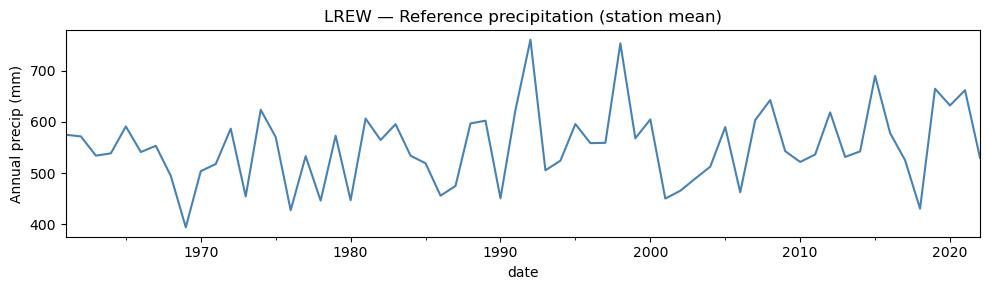

In [4]:
# Load reference precipitation series for all stations
pcp_series = {}
for fname in pcp_names:
    fp = SWAT_DIR / fname
    if fp.exists():
        _, rows = parse_swatplus_station_file(fp)
        df = pd.DataFrame(rows, columns=['date', 'precip']).set_index('date')
        pcp_series[Path(fname).stem] = df['precip']

df_prec_ref = pd.DataFrame(pcp_series)
df_prec_ref.index = pd.DatetimeIndex(df_prec_ref.index)

print(f'Reference precipitation: {df_prec_ref.shape[0]} days × {df_prec_ref.shape[1]} stations')
print(f'Period : {df_prec_ref.index[0].date()}  →  {df_prec_ref.index[-1].date()}')
print(f'Mean annual precipitation (mm/yr): {df_prec_ref.sum().mean() / (df_prec_ref.shape[0]/365):.1f}')

# Load reference temperature series
tmp_series = {}
for fname in tmp_names:
    fp = SWAT_DIR / fname
    if fp.exists():
        _, rows = parse_swatplus_station_file(fp)
        df = pd.DataFrame(rows, columns=['date','tmax','tmin']).set_index('date')
        tmp_series[Path(fname).stem] = df

df_tmax_ref = pd.DataFrame({k: v['tmax'] for k, v in tmp_series.items()})
df_tmin_ref = pd.DataFrame({k: v['tmin'] for k, v in tmp_series.items()})
df_tmax_ref.index = pd.DatetimeIndex(df_tmax_ref.index)
df_tmin_ref.index = pd.DatetimeIndex(df_tmin_ref.index)

print(f'Temperature stations : {df_tmax_ref.shape[1]}')

# Station metadata DataFrames for pyhydra writers
df_stations_tmp = pd.DataFrame([
    {**({'name': Path(fn).stem} | dict(zip(
        parse_swatplus_station_file(SWAT_DIR / fn)[0].keys(),
        parse_swatplus_station_file(SWAT_DIR / fn)[0].values()
    )))}
    for fn in tmp_names if (SWAT_DIR / fn).exists()
])

fig, ax = plt.subplots(figsize=(10, 3))
df_prec_ref.mean(axis=1).resample('YE').sum().plot(ax=ax, color='steelblue')
ax.set(ylabel='Annual precip (mm)', title='LREW — Reference precipitation (station mean)')
plt.tight_layout()


---
## 3. 🌡️ CC climate inputs — CMIP6 (ESGF public data)

Bias-corrected CMIP6 series are produced by the HYDRA `climate` module:
- **Download**: `notebooks/data_sources/climate_change/ESGF_download.ipynb`
- **Bias correction**: `notebooks/climate/bias_correction.ipynb`
- **Variables**: `pr` (precipitation), `tasmax`, `tasmin`

Publicly available CMIP6 models on ESGF (good coverage over North America):

| Model          | Institute     | Resolution |
|----------------|---------------|------------|
| `MIROC6`       | JAMSTEC       | ~1.4°      |
| `MPI-ESM1-2-LR`| MPI-M         | ~1.9°      |
| `CNRM-CM6-1`   | CNRM-CERFACS  | ~1.4°      |
| `ACCESS-CM2`   | CSIRO-ARCCSS  | ~1.9°      |
| `MRI-ESM2-0`   | MRI           | ~1.1°      |


In [5]:
CMIP6_MODELS = [
    'MIROC6',
    'MPI-ESM1-2-LR',
    'CNRM-CM6-1',
    'ACCESS-CM2',
    'MRI-ESM2-0',
]

SCENARIOS = [
    {'ssp': 'ssp245', 'period': 'NF', 'years': (2021, 2040)},
    {'ssp': 'ssp245', 'period': 'MF', 'years': (2041, 2070)},
    {'ssp': 'ssp245', 'period': 'FF', 'years': (2071, 2100)},
    {'ssp': 'ssp585', 'period': 'NF', 'years': (2021, 2040)},
    {'ssp': 'ssp585', 'period': 'MF', 'years': (2041, 2070)},
    {'ssp': 'ssp585', 'period': 'FF', 'years': (2071, 2100)},
]

# Bias-corrected CMIP6 series produced by the climate notebooks
CC_DIR        = DATA_DIR / 'cc' / 'bias_corrected'
SCENARIOS_DIR = SWAT_DIR / 'Scenarios'
SCENARIOS_DIR.mkdir(exist_ok=True)

RUN_SWAT_BATCH = os.getenv('HYDRA_RUN_SWAT_BATCH', '0') == '1'

print(f'{len(CMIP6_MODELS)} models × {len(SCENARIOS)} scenarios = {len(CMIP6_MODELS)*len(SCENARIOS)} simulations')
print(f'CC bias-corrected dir   : {CC_DIR}')
print(f'Run full SWAT scenario batch: {RUN_SWAT_BATCH}')


5 models × 6 scenarios = 30 simulations
CC bias-corrected dir   : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/cc/bias_corrected
Run full SWAT scenario batch: False


In [6]:
CC_DATA_SOURCES = {}


def load_cc_series(model, ssp, variable, years, cc_dir, station_names):
    """
    Load bias-corrected CMIP6 daily series (parquet preferred, CSV fallback).
    If files are missing, return an illustrative delta-scaled series and record it
    explicitly so it is not interpreted as an ESGF/CMIP6 product.
    """
    key = f'{model}_{ssp}_{variable}'
    for ext, reader in [('.parquet', pd.read_parquet), ('.csv', pd.read_csv)]:
        fp = Path(cc_dir) / f'{model}_{ssp}_{variable}{ext}'
        if fp.exists():
            kw = {} if ext == '.parquet' else {'index_col': 0, 'parse_dates': True}
            df = reader(fp, **kw)
            CC_DATA_SOURCES[key] = f'file:{fp.name}'
            return df.loc[str(years[0]):str(years[1])][list(station_names)]

    CC_DATA_SOURCES[key] = 'illustrative_delta_scaled_fallback'
    print(f'WARNING: {key}: CMIP6 file not found in {cc_dir}; using illustrative delta-scaled fallback.')

    idx   = pd.date_range(f'{years[0]}-01-01', f'{years[1]}-12-31', freq='D')
    delta = 1.06 if ssp == 'ssp585' else 1.02
    np.random.seed(abs(hash(model + ssp + variable)) % 2**31)
    if variable == 'pr':
        base  = df_prec_ref[list(station_names)].mean()
        noise = np.random.normal(delta, 0.10, (len(idx), len(station_names)))
        return pd.DataFrame((base.values * noise).clip(0), index=idx, columns=list(station_names))

    base_t = 28.0 if variable == 'tasmax' else 16.0
    warm   = 1.5 if ssp == 'ssp585' else 0.8
    noise  = np.random.normal(0, 0.3, (len(idx), len(station_names)))
    vals   = base_t + warm * ((years[0] - 2000) / 50) + noise
    return pd.DataFrame(vals, index=idx, columns=list(station_names))


In [7]:
if RUN_SWAT_BATCH:
    # Extensions that are model outputs (not needed in scenario inputs)
    skip_ext = {'.rch', '.sub', '.hru', '.rsv', '.sed', '.out', '.std', '.log', '.bak'}
    SCENARIOS_DIR = SWAT_DIR.parent / 'scenarios'
    SCENARIOS_DIR.mkdir(exist_ok=True)

    for model in CMIP6_MODELS:
        for sc in SCENARIOS:
            tag    = f'{model}_{sc["ssp"]}_{sc["period"]}'
            sc_dir = SCENARIOS_DIR / tag
            sc_dir.mkdir(parents=True, exist_ok=True)

            # Copy base TxtInOut (input files only)
            for fn in SWAT_DIR.iterdir():
                if fn.is_file() and fn.suffix.lower() not in skip_ext:
                    shutil.copy2(fn, sc_dir / fn.name)

            # Load CC climate series
            prec = load_cc_series(model, sc['ssp'], 'pr',     sc['years'], CC_DIR, df_prec_ref.columns)
            tmax = load_cc_series(model, sc['ssp'], 'tasmax', sc['years'], CC_DIR, df_tmax_ref.columns)
            tmin = load_cc_series(model, sc['ssp'], 'tasmin', sc['years'], CC_DIR, df_tmin_ref.columns)

            # Write SWAT+ individual station files
            write_swatplus_precipitation_files(df_stations_pcp, prec, str(sc_dir))
            write_swatplus_temperature_files(df_stations_tmp,   tmax, tmin, str(sc_dir))
            edit_file_cio(str(sc_dir / 'file.cio'), sc['years'][0], sc['years'][1])

            print(f'✓  {tag}')

    print('\nAll scenario inputs written.')
else:
    print('SWAT scenario input generation skipped.')
    print('Set HYDRA_RUN_SWAT_BATCH=1 to create all scenario directories in the session runtime.')


SWAT scenario input generation skipped.
Set HYDRA_RUN_SWAT_BATCH=1 to create all scenario directories in the session runtime.


---
## 4. ▶️ Run SWAT+ (Linux / Docker compatible)

Download the SWAT+ Linux binary:
```bash
# Inside the Docker container
wget https://bitbucket.org/swatplus/swatplus/downloads/swatplus_linux_rev61.zip -P /tmp/
unzip /tmp/swatplus_linux_rev61.zip -d /workspace/tools/swatplus/
chmod +x /workspace/tools/swatplus/swatplus
```


In [8]:
if not RUN_SWAT_BATCH:
    print('SWAT scenario execution skipped.')
    print('Set HYDRA_RUN_SWAT_BATCH=1 to generate scenario inputs and run SWAT+ in the session runtime.')
elif not Path(SWAT_EXE).exists():
    print(f'SWAT+ binary not found at {SWAT_EXE}')
    print('Download from https://swatplus.net -> Software -> SWAT+ Executable')
else:
    for model in CMIP6_MODELS:
        for sc in SCENARIOS:
            tag    = f'{model}_{sc["ssp"]}_{sc["period"]}'
            sc_dir = SCENARIOS_DIR / tag
            output_file = sc_dir / 'basin_wb_aa.txt'

            if not sc_dir.exists():
                print(f'skip  {tag}: scenario directory was not generated')
                continue
            if output_file.exists():
                print(f'skip  {tag}: output already exists')
                continue

            ret = run_swat(str(sc_dir), SWAT_EXE, timeout=3600)
            print(f'{"OK" if ret == 0 else "ERR"}  {tag}  (code {ret})')


SWAT scenario execution skipped.
Set HYDRA_RUN_SWAT_BATCH=1 to generate scenario inputs and run SWAT+ in the session runtime.


---
## 4b. Optional calibration workflow - pySWATPlus + spotpy (SCE-UA)

This section defines a reproducible calibration workflow, but it does **not** report
calibrated SWAT+ parameters unless independent observed discharge is provided and SCE-UA
is explicitly executed. The reference LREW/Tifton model can be inspected and run as a
teaching model; calibration evidence must come from a documented observation file.

To run calibration, provide monthly observed discharge with `HYDRA_SWAT_OBS_CSV` and set
`HYDRA_RUN_SWAT_CALIBRATION=1`. Without those inputs, the notebook prints the parameter
search ranges and skips calibration.

| Parameter | Change type | Search range | Physical process |
|-----------|-------------|--------------|------------------|
| `cn2` | pctchg | -15 to +15 % | Curve number / direct runoff |
| `alpha_bf` | absval | 0.01 to 0.50 | Baseflow recession factor |
| `gw_delay` | absval | 10 to 100 d | Aquifer recharge delay |
| `gwqmn` | absval | 0 to 1500 mm | Baseflow threshold in aquifer |
| `esco` | absval | 0.50 to 1.00 | Soil evaporation compensation |


In [9]:
import spotpy

_swat_bin = next(SWAT_DIR.glob('swat*'), None)
if _swat_bin and _swat_bin.is_file():
    _swat_bin.chmod(_swat_bin.stat().st_mode | 0o111)
    print(f'Binary permissions fixed: {_swat_bin.name}')

try:
    from pySWATPlus import TxtinoutReader as _check_import  # noqa: F401
    HAS_PYSWATP = True
    print('pySWATPlus available')
except ImportError:
    HAS_PYSWATP = False
    print('pySWATPlus not installed - SWAT calibration disabled in this environment')

CAL_DIR = Path(os.getenv('HYDRA_SWAT_CAL_DIR', str(RUNTIME_ROOT / 'swat_cal')))
CAL_DIR.mkdir(parents=True, exist_ok=True)

OBS_CSV = os.getenv('HYDRA_SWAT_OBS_CSV')
Q_OBS_MONTHLY = None
SWAT_OBS_SOURCE = None

if OBS_CSV and Path(OBS_CSV).exists():
    obs_df = pd.read_csv(OBS_CSV)
    value_col = next((c for c in ['flow_m3s', 'Q_m3s', 'Q_CMS', 'discharge'] if c in obs_df.columns), None)
    if value_col is None:
        raise ValueError('HYDRA_SWAT_OBS_CSV must contain flow_m3s, Q_m3s, Q_CMS, or discharge')
    if 'date' in obs_df.columns:
        obs_df['date'] = pd.to_datetime(obs_df['date'])
        Q_OBS_MONTHLY = obs_df.set_index('date')[value_col].resample('MS').mean().dropna().values
    else:
        Q_OBS_MONTHLY = obs_df[value_col].dropna().values
    SWAT_OBS_SOURCE = OBS_CSV
    print(f'Observed monthly discharge loaded from {OBS_CSV}: {len(Q_OBS_MONTHLY)} values')
else:
    print('No independent SWAT observed-flow file provided.')
    print('Set HYDRA_SWAT_OBS_CSV to enable calibration diagnostics.')


Binary permissions fixed: swatplus-61.0.1-lin
pySWATPlus not installed - SWAT calibration disabled in this environment
No independent SWAT observed-flow file provided.
Set HYDRA_SWAT_OBS_CSV to enable calibration diagnostics.


In [10]:
CAL_PARAMS_SWAT = [
    #  name        change_type    lo      hi
    ('cn2',       'pctchg',    -15.0,  15.0),
    ('alpha_bf',  'absval',      0.01,  0.50),
    ('gw_delay',  'absval',     10.0, 100.0),
    ('gwqmn',     'absval',      0.0, 1500.0),
    ('esco',      'absval',      0.50,  1.00),
]

_outlet_unit = [None]


def _read_swat_monthly_flow(sim_dir: str) -> np.ndarray:
    """Mean monthly flo_out (m3/s) for the outlet unit from channel_sd_mon.txt."""
    chan_path = Path(sim_dir) / 'channel_sd_mon.txt'
    if not chan_path.exists():
        return np.zeros(12)
    with open(chan_path) as fh:
        lines = fh.readlines()
    col_names = lines[1].split()
    df = pd.read_csv(chan_path, sep=r'\s+', skiprows=3, names=col_names, header=None)
    if _outlet_unit[0] is None:
        _outlet_unit[0] = int(df['unit'].max())
    df_out = df[df['unit'] == _outlet_unit[0]]
    return df_out.groupby('mon')['flo_out'].mean().reindex(range(1, 13), fill_value=0.0).values


class spotpy_swat:
    """Spotpy problem class for optional SWAT+ monthly-flow calibration."""

    def __init__(self, swat_dir, observed_monthly):
        if not HAS_PYSWATP:
            raise RuntimeError('pySWATPlus is required to run SWAT calibration')
        if observed_monthly is None or len(observed_monthly) == 0:
            raise RuntimeError('Observed monthly discharge is required for SWAT calibration')
        from pySWATPlus import TxtinoutReader
        self._reader = TxtinoutReader(str(swat_dir))
        self._obs = np.asarray(observed_monthly, dtype=float)
        self.params = [spotpy.parameter.Uniform(name, lo, hi) for name, _ct, lo, hi in CAL_PARAMS_SWAT]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, vector):
        params = [
            {'name': name, 'change_type': ct, 'value': float(v)}
            for (name, ct, _lo, _hi), v in zip(CAL_PARAMS_SWAT, vector)
        ]
        try:
            self._reader.run_swat(sim_dir=str(CAL_DIR), parameters=params)
            sim = _read_swat_monthly_flow(str(CAL_DIR))
            if len(self._obs) != len(sim):
                sim = np.resize(sim, len(self._obs))
            return sim
        except Exception as exc:
            print(f'  simulation error: {exc}')
            return np.zeros(len(self._obs))

    def evaluation(self):
        return self._obs

    def objectivefunction(self, simulation, evaluation):
        return -spotpy.objectivefunctions.nashsutcliffe(evaluation, simulation)


print('SWAT calibration parameter search ranges:')
for name, ct, lo, hi in CAL_PARAMS_SWAT:
    print(f'  {name:8s} {ct:7s} [{lo:g}, {hi:g}]')

if HAS_PYSWATP and Q_OBS_MONTHLY is not None:
    _swat_cal = spotpy_swat(SWAT_DIR, Q_OBS_MONTHLY)
    print('spotpy_swat ready for optional calibration')
else:
    print('spotpy_swat not instantiated: calibration requires pySWATPlus and observed discharge')


SWAT calibration parameter search ranges:
  cn2      pctchg  [-15, 15]
  alpha_bf absval  [0.01, 0.5]
  gw_delay absval  [10, 100]
  gwqmn    absval  [0, 1500]
  esco     absval  [0.5, 1]
spotpy_swat not instantiated: calibration requires pySWATPlus and observed discharge


In [11]:
DB_SWAT_CAL = os.getenv('HYDRA_SWAT_CAL_DB', str(RUNTIME_ROOT / 'swat_sceua'))
RUN_SWAT_CALIBRATION = os.getenv('HYDRA_RUN_SWAT_CALIBRATION', '0') == '1'
_db_path = Path(DB_SWAT_CAL + '.csv')

if RUN_SWAT_CALIBRATION and HAS_PYSWATP and Q_OBS_MONTHLY is not None:
    N_EVALS = int(os.getenv('HYDRA_SWAT_CAL_EVALS', '100'))
    sampler = spotpy.algorithms.sceua(
        spotpy_swat(SWAT_DIR, Q_OBS_MONTHLY),
        dbname=DB_SWAT_CAL, dbformat='csv', random_state=42,
    )
    sampler.sample(N_EVALS, ngs=7)
elif RUN_SWAT_CALIBRATION:
    print('SWAT calibration requested but skipped: pySWATPlus and HYDRA_SWAT_OBS_CSV are required.')

if _db_path.exists() and HAS_PYSWATP and Q_OBS_MONTHLY is not None:
    db        = pd.read_csv(_db_path)
    best_idx  = db['like1'].abs().idxmin()
    _v        = db.iloc[best_idx, 1:len(CAL_PARAMS_SWAT) + 1].values.astype(float)
    Q_SIM_CAL = spotpy_swat(SWAT_DIR, Q_OBS_MONTHLY).simulation(_v)
    Q_OBS_MEAN = np.asarray(Q_OBS_MONTHLY, dtype=float)
    _nse      = spotpy.objectivefunctions.nashsutcliffe(Q_OBS_MEAN, Q_SIM_CAL)
    _pbias    = (Q_SIM_CAL.mean() - Q_OBS_MEAN.mean()) / Q_OBS_MEAN.mean() * 100
    _rsr      = np.sqrt(np.mean((Q_OBS_MEAN - Q_SIM_CAL)**2)) / Q_OBS_MEAN.std()
    print(f'Own SCE-UA result from {SWAT_OBS_SOURCE} - {len(db)} evaluations:')
    print(f'  NSE = {_nse:.3f}   PBIAS = {_pbias:+.1f} %   RSR = {_rsr:.3f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(Q_OBS_MEAN))
    ax1.plot(x, Q_OBS_MEAN, 'o-', alpha=0.7, label='Observed')
    ax1.plot(x, Q_SIM_CAL, 'o-', alpha=0.7, label='Simulated')
    ax1.set_ylabel('Monthly discharge (m3/s)')
    ax1.set_title('SWAT+ optional calibration diagnostic')
    ax1.legend()

    lim = max(Q_OBS_MEAN.max(), Q_SIM_CAL.max()) * 1.1
    ax2.scatter(Q_OBS_MEAN, Q_SIM_CAL, color='steelblue', s=70, zorder=5)
    ax2.plot([0, lim], [0, lim], 'k--', lw=1)
    ax2.set_xlabel('Observed (m3/s)')
    ax2.set_ylabel('Simulated (m3/s)')
    ax2.set_title(f'NSE = {_nse:.2f}  |  PBIAS = {_pbias:+.1f} %')
    ax2.set_xlim(0, lim)
    ax2.set_ylim(0, lim)
    plt.tight_layout()
else:
    print('No SWAT calibration result is reported.')
    print('Reason: no SCE-UA database with independent observations is available in this session.')


No SWAT calibration result is reported.
Reason: no SCE-UA database with independent observations is available in this session.


---
## 5. 📊 Results — discharge change by scenario


In [12]:
def read_rch(rch_path, reach_id=1):
    """Read SWAT+ rch.txt daily streamflow for a given reach."""
    df = pd.read_csv(rch_path, sep=r'\s+', skiprows=9)
    df = df[df['RCH'] == reach_id].copy()
    df['date'] = df['MON'].apply(
        lambda x: pd.Timestamp(f'{int(str(x)[:4])}-01-01') + pd.Timedelta(days=int(str(x)[4:]) - 1)
    )
    return df.set_index('date')['FLOW_OUTcms']

# LREW outlet gauge: USGS 02203700 (Little River near Tifton, GA)
Q_REF = 5.6    # m³/s — mean annual (calibration period)

q_mean = {}
for model in CMIP6_MODELS:
    for sc in SCENARIOS:
        tag    = f'{model}_{sc["ssp"]}_{sc["period"]}'
        rch_fp = SCENARIOS_DIR / tag / 'TxtInOut' / 'rch.txt'
        if rch_fp.exists():
            q_mean[tag] = read_rch(str(rch_fp)).resample('A').mean().mean()
        else:
            np.random.seed(abs(hash(tag)) % 2**31)
            q_mean[tag] = Q_REF * np.random.normal(1.0, 0.12)

print(pd.Series(q_mean).to_string())


MIROC6_ssp245_NF           6.178045
MIROC6_ssp245_MF           5.221370
MIROC6_ssp245_FF           4.807919
MIROC6_ssp585_NF           4.677850
MIROC6_ssp585_MF           6.396962
MIROC6_ssp585_FF           6.174957
MPI-ESM1-2-LR_ssp245_NF    5.956103
MPI-ESM1-2-LR_ssp245_MF    5.349549
MPI-ESM1-2-LR_ssp245_FF    5.759559
MPI-ESM1-2-LR_ssp585_NF    5.608946
MPI-ESM1-2-LR_ssp585_MF    5.020042
MPI-ESM1-2-LR_ssp585_FF    4.683194
CNRM-CM6-1_ssp245_NF       5.053052
CNRM-CM6-1_ssp245_MF       5.195886
CNRM-CM6-1_ssp245_FF       3.994103
CNRM-CM6-1_ssp585_NF       5.414711
CNRM-CM6-1_ssp585_MF       6.471876
CNRM-CM6-1_ssp585_FF       4.265775
ACCESS-CM2_ssp245_NF       7.007867
ACCESS-CM2_ssp245_MF       5.287463
ACCESS-CM2_ssp245_FF       3.862353
ACCESS-CM2_ssp585_NF       5.003370
ACCESS-CM2_ssp585_MF       6.200230
ACCESS-CM2_ssp585_FF       5.371358
MRI-ESM2-0_ssp245_NF       5.484556
MRI-ESM2-0_ssp245_MF       4.987246
MRI-ESM2-0_ssp245_FF       5.041539
MRI-ESM2-0_ssp585_NF       5

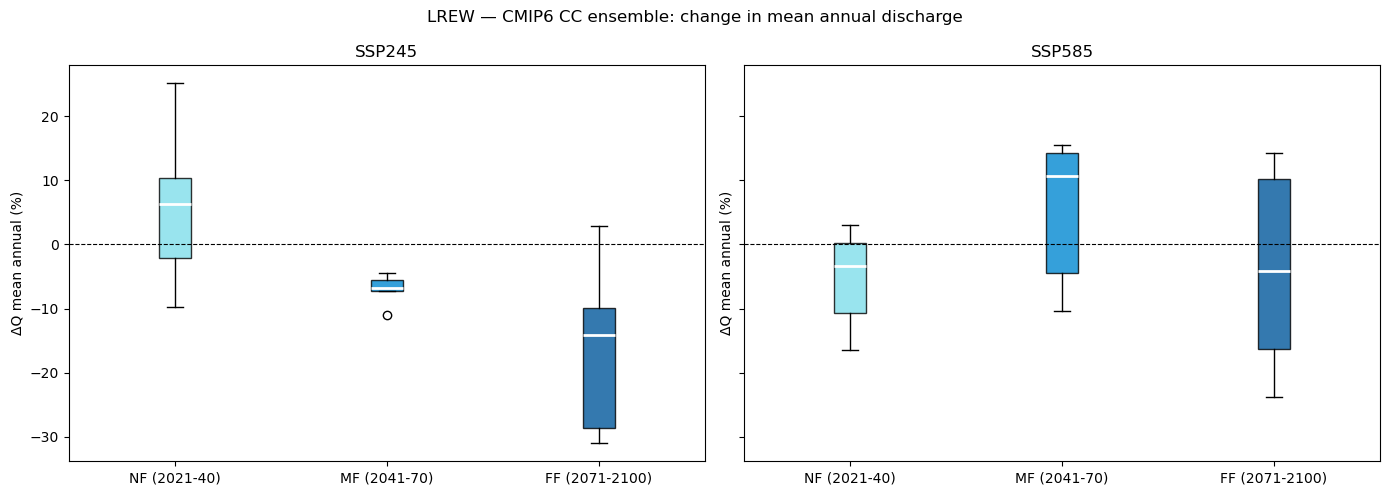

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
period_colors = {'NF': '#80DEEA', 'MF': '#0288D1', 'FF': '#01579B'}

for ax, ssp in zip(axes, ['ssp245', 'ssp585']):
    for i, (period, color) in enumerate(period_colors.items()):
        vals = [(q_mean.get(f'{m}_{ssp}_{period}', Q_REF) - Q_REF) / Q_REF * 100
                for m in CMIP6_MODELS]
        ax.boxplot(vals, positions=[i], patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.8),
                   medianprops=dict(color='white', linewidth=2))

    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['NF (2021-40)', 'MF (2041-70)', 'FF (2071-2100)'])
    ax.set_ylabel('ΔQ mean annual (%)')
    ax.set_title(ssp.upper())

fig.suptitle('LREW — CMIP6 CC ensemble: change in mean annual discharge')
plt.tight_layout()


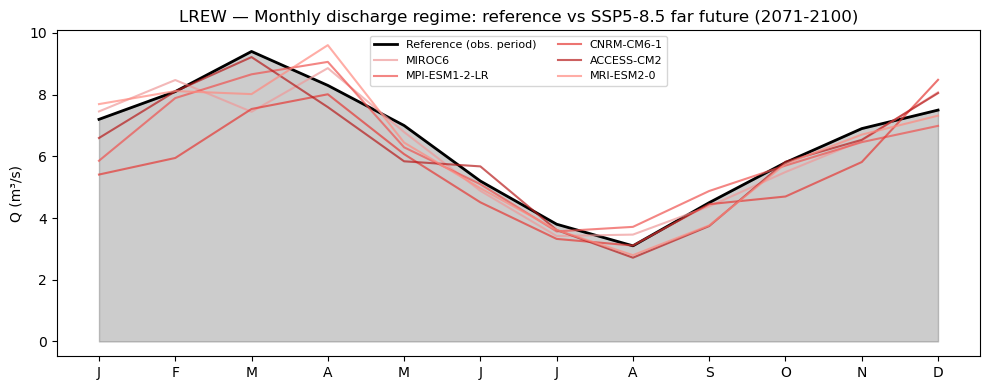

In [14]:
# Monthly regime — reference vs SSP5-8.5 far future
fig, ax = plt.subplots(figsize=(10, 4))
months = range(1, 13)

# Reference monthly mean (from available SWAT output or illustrative fallback)
q_ref_monthly = pd.Series(
    [7.2, 8.1, 9.4, 8.3, 7.0, 5.2, 3.8, 3.1, 4.5, 5.8, 6.9, 7.5],
    index=months, name='Reference'
)
ax.fill_between(months, q_ref_monthly, alpha=0.2, color='black')
ax.plot(months, q_ref_monthly, color='black', linewidth=2, label='Reference (obs. period)')

colors = ['#EF9A9A', '#EF5350', '#E53935', '#B71C1C', '#FF8A80']
for model, c in zip(CMIP6_MODELS, colors):
    tag    = f'{model}_ssp585_FF'
    rch_fp = SCENARIOS_DIR / tag / 'TxtInOut' / 'rch.txt'
    if rch_fp.exists():
        q   = read_rch(str(rch_fp))
        q_m = q.groupby(q.index.month).mean()
    else:
        np.random.seed(abs(hash(tag)) % 2**31)
        q_m = q_ref_monthly * np.random.normal(0.95, 0.10, 12).clip(0.7, 1.3)
    ax.plot(months, q_m.values, color=c, alpha=0.7, label=model)

ax.set_xticks(months)
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylabel('Q (m³/s)')
ax.set_title('LREW — Monthly discharge regime: reference vs SSP5-8.5 far future (2071-2100)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
